# Tennis Data Analysis — Part 1: Data Loading & Cleaning


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

You can upload files directly to your Colab environment using the following code. After running the cell, you will be prompted to choose a file from your local machine. Once uploaded, `data.csv` will be accessible in the current session.

In [ ]:
from google.colab import files

# Upload the file from your local system
uploaded = files.upload()

# If you want to confirm the file is uploaded and available
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving 2019-usopen-points.csv to 2019-usopen-points.csv
Saving 2020-usopen-points.csv to 2020-usopen-points.csv
Saving 2021-usopen-points.csv to 2021-usopen-points.csv
Saving 2022-usopen-points.csv to 2022-usopen-points.csv
Saving 2023-usopen-points.csv to 2023-usopen-points.csv
Saving 2024-usopen-points.csv to 2024-usopen-points.csv
User uploaded file "2019-usopen-points.csv" with length 7480927 bytes
User uploaded file "2020-usopen-points.csv" with length 7074131 bytes
User uploaded file "2021-usopen-points.csv" with length 7727334 bytes
User uploaded file "2022-usopen-points.csv" with length 7572634 bytes
User uploaded file "2023-usopen-points.csv" with length 7304490 bytes
User uploaded file "2024-usopen-points.csv" with length 7260912 bytes


After uploading, you can then read the CSV file into a pandas DataFrame:

In [ ]:
import io

# Create a dictionary to store individual DataFrames
all_dfs = {}

# Iterate through each uploaded file and read it into a DataFrame
for filename, content in uploaded.items():
  print(f'Reading file: {filename}')
  # Assuming all uploaded files are CSVs, you can adjust for other formats
  df_name = 'df'+ filename.split('-')[0] # Use filename without extension as df name
  all_dfs[df_name] = pd.read_csv(io.StringIO(content.decode('utf-8')))
  print(f'Successfully loaded {filename} into DataFrame: {df_name}')

Reading file: 2019-usopen-points.csv
Successfully loaded 2019-usopen-points.csv into DataFrame: df2019
Reading file: 2020-usopen-points.csv
Successfully loaded 2020-usopen-points.csv into DataFrame: df2020
Reading file: 2021-usopen-points.csv
Successfully loaded 2021-usopen-points.csv into DataFrame: df2021
Reading file: 2022-usopen-points.csv
Successfully loaded 2022-usopen-points.csv into DataFrame: df2022
Reading file: 2023-usopen-points.csv
Successfully loaded 2023-usopen-points.csv into DataFrame: df2023
Reading file: 2024-usopen-points.csv
Successfully loaded 2024-usopen-points.csv into DataFrame: df2024


In [ ]:
all_dfs['df2019'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47893 entries, 0 to 47892
Data columns (total 65 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   match_id            47893 non-null  object 
 1   ElapsedTime         47893 non-null  object 
 2   SetNo               47893 non-null  int64  
 3   P1GamesWon          47893 non-null  int64  
 4   P2GamesWon          47893 non-null  int64  
 5   SetWinner           47893 non-null  int64  
 6   GameNo              47893 non-null  int64  
 7   GameWinner          47893 non-null  int64  
 8   PointNumber         47893 non-null  object 
 9   PointWinner         47893 non-null  int64  
 10  PointServer         47893 non-null  int64  
 11  Speed_KMH           47893 non-null  int64  
 12  Rally               0 non-null      float64
 13  P1Score             47893 non-null  object 
 14  P2Score             47893 non-null  object 
 15  P1Momentum          47893 non-null  int64  
 16  P2Mo

First, let's check if all DataFrames have the same columns. We'll compare the columns of `df2019` with the others.

In [ ]:
# Get column names for df2019
ref_columns = set(all_dfs['df2019'].columns)

# Check if all other DataFrames have the same columns
consistent_columns = True
for name, df in all_dfs.items():
  if name != 'df2019': # Skip comparing with itself
    current_columns = set(df.columns)
    if ref_columns != current_columns:
      print(f"DataFrame '{name}' has different columns than 'df2019'.")
      print(f"Columns in 'df2019': {ref_columns}")
      print(f"Columns in '{name}': {current_columns}")
      consistent_columns = False
    else:
      print(f"DataFrame '{name}' has consistent columns with 'df2019'.")

if consistent_columns:
  print("\nAll DataFrames have consistent column names.")
else:
  print("\nSome DataFrames have inconsistent column names. You might need to preprocess them before merging.")

DataFrame 'df2020' has consistent columns with 'df2019'.
DataFrame 'df2021' has consistent columns with 'df2019'.
DataFrame 'df2022' has consistent columns with 'df2019'.
DataFrame 'df2023' has consistent columns with 'df2019'.
DataFrame 'df2024' has consistent columns with 'df2019'.

All DataFrames have consistent column names.


Next, let's check for data type consistency across common columns. We'll focus on `df2019` as the reference.

In [ ]:
# Get data types for df2019
ref_dtypes = all_dfs['df2019'].dtypes

consistent_dtypes = True
for name, df in all_dfs.items():
  if name == 'df2019':
    continue

  current_dtypes = df.dtypes
  for col in ref_columns:
    if col in current_dtypes and ref_dtypes[col] != current_dtypes[col]:
      print(f"Data type mismatch for column '{col}' between 'df2019' ({ref_dtypes[col]}) and '{name}' ({current_dtypes[col]}).")
      consistent_dtypes = False

if consistent_dtypes:
  print("\nAll DataFrames have consistent data types for common columns.")
else:
  print("\nSome DataFrames have inconsistent data types for common columns. You might need to cast them before merging.")



All DataFrames have consistent data types for common columns.


Once these checks pass, you can combine them using `pd.concat()`. If there are inconsistencies, you'll need to address them first.

In [ ]:
all_points = pd.concat(all_dfs.values(), ignore_index=True)

all_points.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278894 entries, 0 to 278893
Data columns (total 65 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   match_id            278894 non-null  object 
 1   ElapsedTime         278894 non-null  object 
 2   SetNo               278894 non-null  int64  
 3   P1GamesWon          278894 non-null  int64  
 4   P2GamesWon          278894 non-null  int64  
 5   SetWinner           278894 non-null  int64  
 6   GameNo              278894 non-null  int64  
 7   GameWinner          278894 non-null  int64  
 8   PointNumber         278894 non-null  object 
 9   PointWinner         278894 non-null  int64  
 10  PointServer         278894 non-null  int64  
 11  Speed_KMH           278894 non-null  int64  
 12  Rally               0 non-null       float64
 13  P1Score             278894 non-null  object 
 14  P2Score             278894 non-null  object 
 15  P1Momentum          278894 non-nul

In [ ]:
df1 = all_points.copy()

In [ ]:
empty_columns = [col for col in df1.columns if df1[col].isnull().all()]

if empty_columns:
    print(f"Dropping the following completely empty columns: {empty_columns}")
    df1.drop(columns=empty_columns, inplace=True)
    print("Empty columns removed successfully.")
else:
    print("No completely empty columns found in df1.")

df1.info()

Dropping the following completely empty columns: ['Rally', 'P1FirstSrvIn', 'P2FirstSrvIn', 'P1FirstSrvWon', 'P2FirstSrvWon', 'P1SecondSrvIn', 'P2SecondSrvIn', 'P1SecondSrvWon', 'P2SecondSrvWon', 'P1ForcedError', 'P2ForcedError', 'Serve_Direction', 'Winner_FH', 'Winner_BH', 'ServingTo', 'P1TurningPoint', 'P2TurningPoint']
Empty columns removed successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278894 entries, 0 to 278893
Data columns (total 48 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   match_id            278894 non-null  object 
 1   ElapsedTime         278894 non-null  object 
 2   SetNo               278894 non-null  int64  
 3   P1GamesWon          278894 non-null  int64  
 4   P2GamesWon          278894 non-null  int64  
 5   SetWinner           278894 non-null  int64  
 6   GameNo              278894 non-null  int64  
 7   GameWinner          278894 non-null  int64  
 8   PointNumber         27889

In [ ]:
#remove column 'History'(i can't find the meaning of this column so won't use it) and 'Speed_KMH'(repeat with Speed_MPH)
df1 = df1.drop(columns=['History', 'Speed_KMH'])

In [ ]:
df1['PointNumber'].unique()

array(['0X', '0Y', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10',
       '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21',
       '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32',
       '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43',
       '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54',
       '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65',
       '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76',
       '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87',
       '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98',
       '99', '100', '101', '102', '103', '104', '105', '106', '107',
       '108', '109', '110', '111', '112', '113', '114', '115', '116',
       '117', '118', '119', '120', '121', '122', '123', '124', '125',
       '126', '127', '128', '129', '130', '131', '132', '133', '134',
       '135', '136', '137', '138', '139', '140', '141', '142', '143

In [ ]:
df1[df1['PointNumber'] == '20Y']

,match_id,ElapsedTime,SetNo,P1GamesWon,P2GamesWon,SetWinner,GameNo,GameWinner,PointNumber,PointWinner,...,ServeIndicator,ServeNumber,WinnerType,WinnerShotType,P1DistanceRun,P2DistanceRun,RallyCount,ServeWidth,ServeDepth,ReturnDepth
150222,2022-usopen-1143,0,1,0,0,0,5,0,20Y,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
150490,2022-usopen-1144,0,1,0,0,0,3,0,20Y,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN


In [ ]:
#remove rows that ElapsedTime = 0, which are extral records
df1 = df1[df1['ElapsedTime'] != '0']

In [ ]:
df1[(df1['PointNumber'] == '0X') | (df1['PointNumber'] == '0Y')]

,match_id,ElapsedTime,SetNo,P1GamesWon,P2GamesWon,SetWinner,GameNo,GameWinner,PointNumber,PointWinner,...,ServeIndicator,ServeNumber,WinnerType,WinnerShotType,P1DistanceRun,P2DistanceRun,RallyCount,ServeWidth,ServeDepth,ReturnDepth
0,2019-usopen-1101,0:00:00,1,0,0,0,1,0,0X,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
1,2019-usopen-1101,0:00:00,1,0,0,0,1,0,0Y,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
166,2019-usopen-1102,0:00:00,1,0,0,0,1,0,0X,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
167,2019-usopen-1102,0:00:00,1,0,0,0,1,0,0Y,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
402,2019-usopen-1103,0:00:00,1,0,0,0,1,0,0X,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278416,2024-usopen-2601,0:00:00,1,0,0,0,1,0,0Y,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
278591,2024-usopen-2602,0:00:00,1,0,0,0,1,0,0X,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
278592,2024-usopen-2602,0:00:00,1,0,0,0,1,0,0Y,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN
278725,2024-usopen-2701,0:00:00,1,0,0,0,1,0,0X,0,...,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN


In [ ]:
#remove rows that has PointNumber = '0X' or '0Y'. these are rows used to separate different matches
df1 = df1[(df1['PointNumber'] != '0X') & (df1['PointNumber'] != '0Y')]

In [ ]:
df1['PointNumber'].unique()

array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34',
       '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45',
       '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56',
       '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67',
       '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78',
       '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89',
       '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100',
       '101', '102', '103', '104', '105', '106', '107', '108', '109',
       '110', '111', '112', '113', '114', '115', '116', '117', '118',
       '119', '120', '121', '122', '123', '124', '125', '126', '127',
       '128', '129', '130', '131', '132', '133', '134', '135', '136',
       '137', '138', '139', '140', '141', '142', '143', '144', '1

In [ ]:
df1['P1Score'].unique()

array(['15', '30', '40', '0', 'AD', '1', '2', '3', '4', '5', '6', '7',
       '8', '9', '10', '11', '12', '13', '14'], dtype=object)

In [ ]:
df1['P2Score'].unique()

array(['0', '15', '30', '40', 'AD', '1', '2', '3', '4', '5', '6', '7',
       '8', '9', '10', '11', '12', '13', '14'], dtype=object)

In [ ]:
#the Score has both string and int in tennis, we can't change P1Score and P2Score to int64 datatype. We won't use these two variables later.
#we only change PointNumber from object to int64type
df1['PointNumber'] = pd.to_numeric(df1['PointNumber'], errors='coerce')

In [ ]:
df1.isna().sum()

,0
match_id,0
ElapsedTime,0
SetNo,0
P1GamesWon,0
P2GamesWon,0
SetWinner,0
GameNo,0
GameWinner,0
PointNumber,0
PointWinner,0


In [ ]:
(df1['RallyCount'] == 0).sum()

np.int64(35826)

In [ ]:

cols = [
  'SetNo',
  'RallyCount',
  'ServeIndicator',
  'ServeNumber',
  'PointNumber',
  'P1PointsWon',
  'P2PointsWon',
  'P1Ace',
  'P2Ace',
  'P1Winner',
  'P2Winner',
  'P1DoubleFault',
  'P2DoubleFault',
  'P1UnfErr',
  'P2UnfErr',
  'P1NetPoint',
  'P2NetPoint',
  'P1NetPointWon',
  'P2NetPointWon',
  'P1BreakPoint',
  'P2BreakPoint',
  'P1BreakPointWon',
  'P2BreakPointWon',
  'P1DistanceRun',
  'P2DistanceRun',
  'Speed_MPH'
]


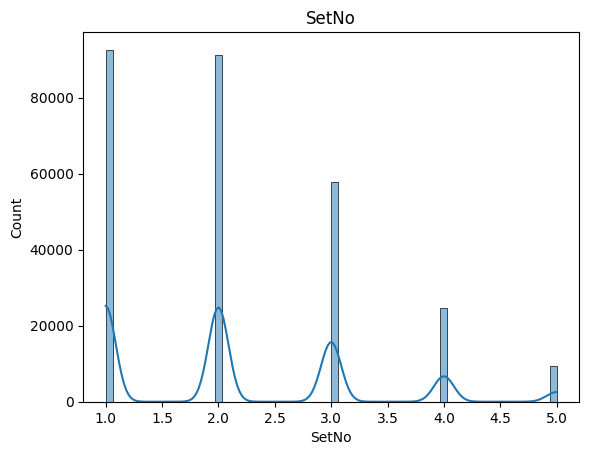

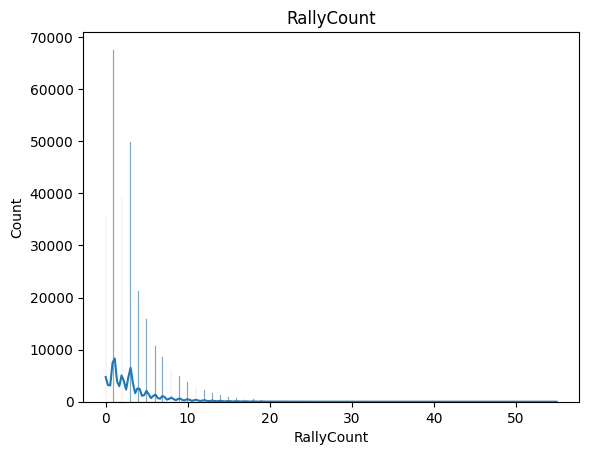

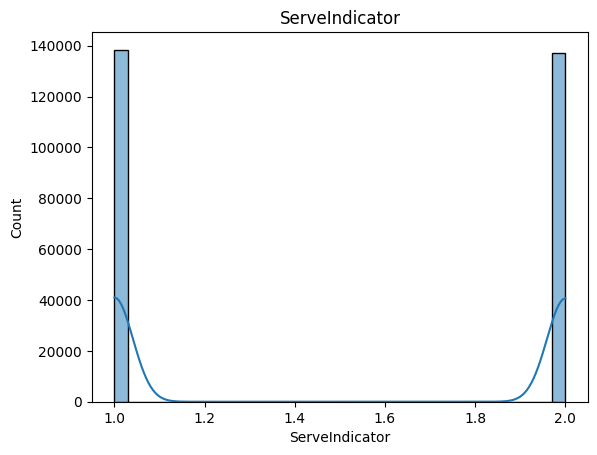

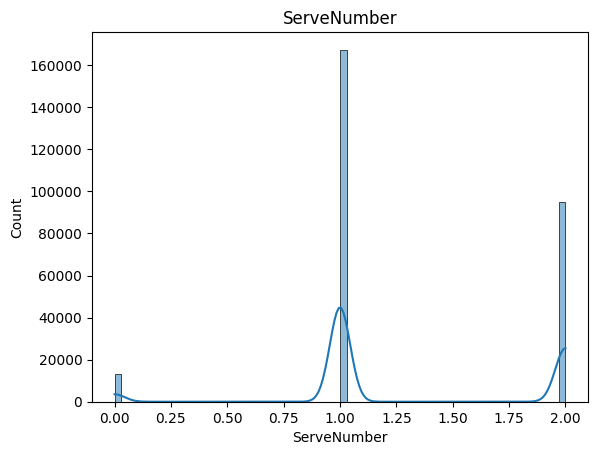

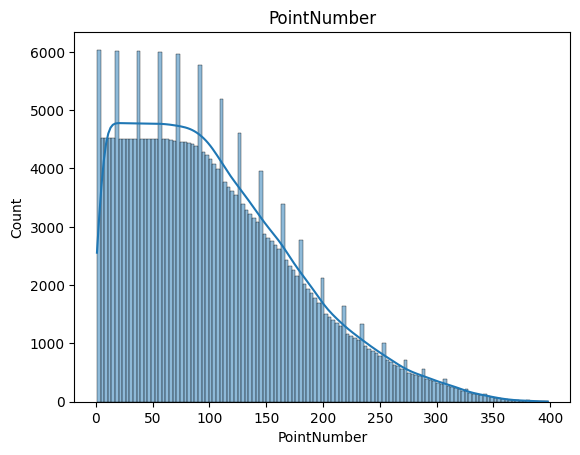

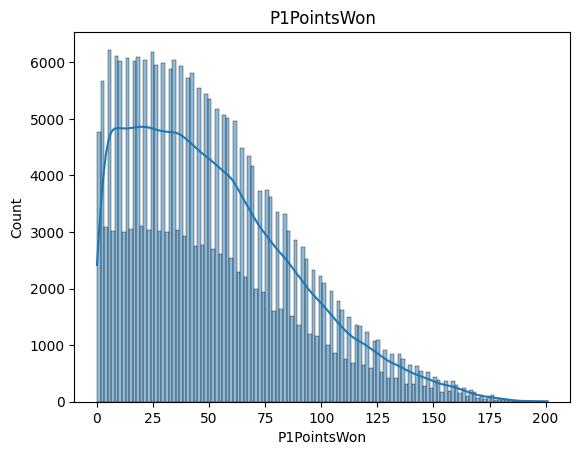

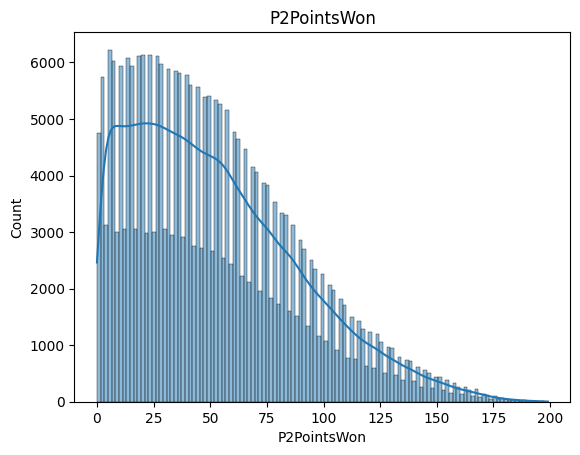

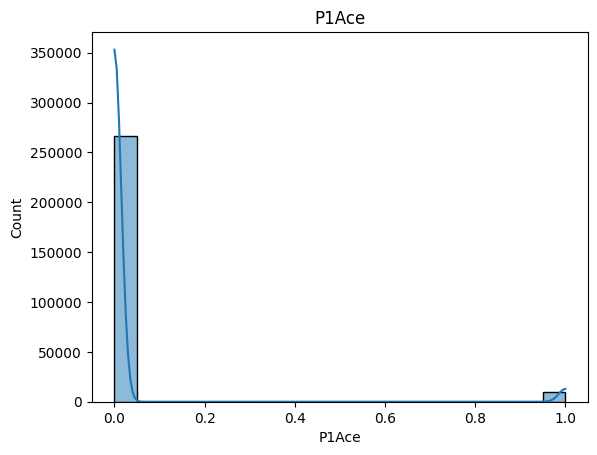

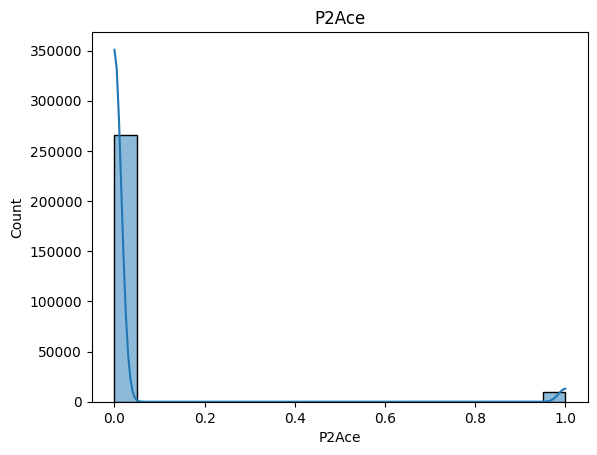

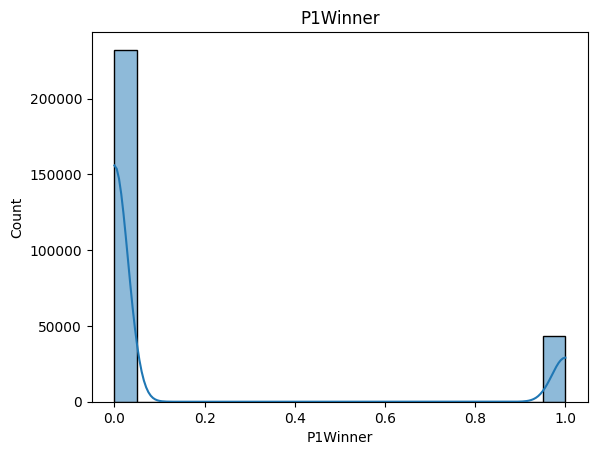

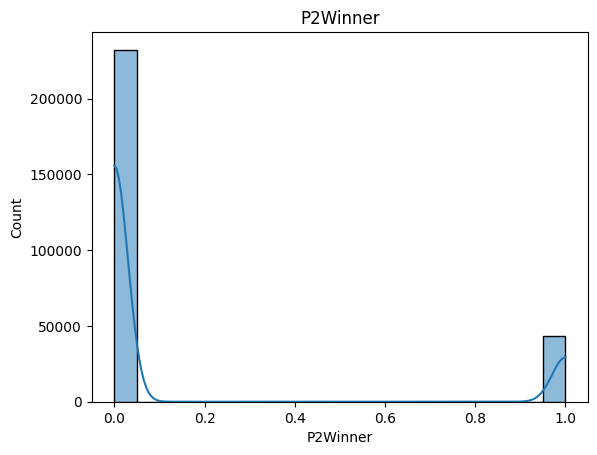

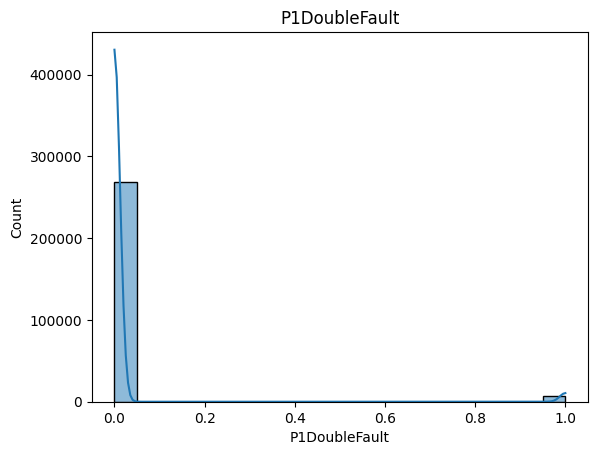

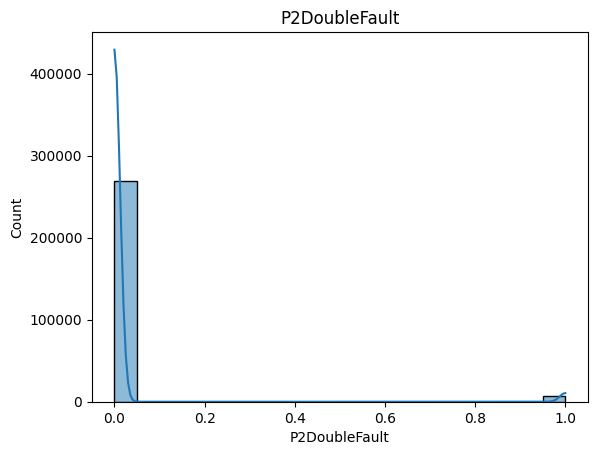

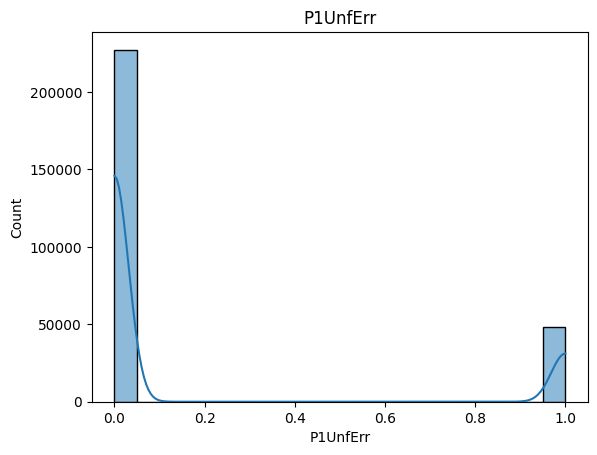

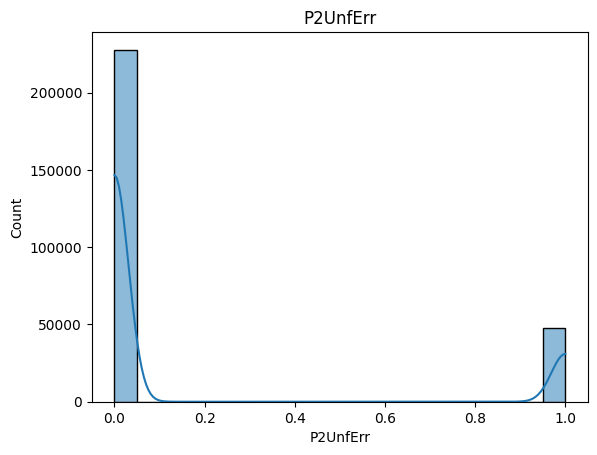

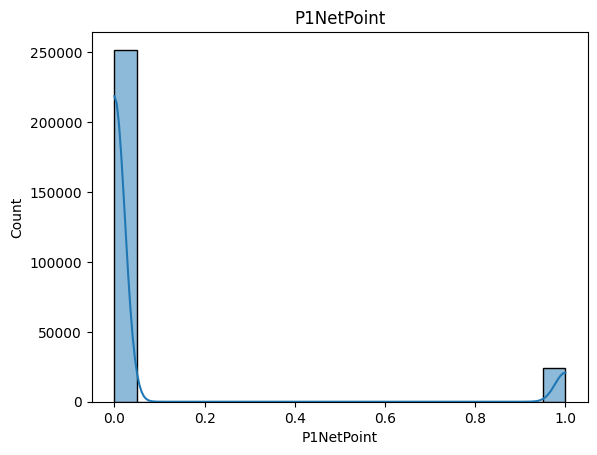

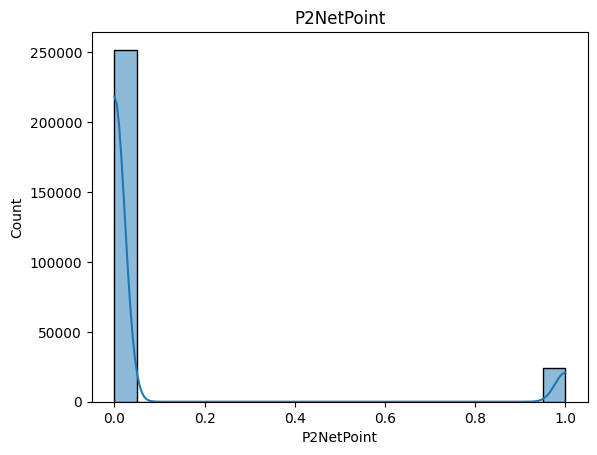

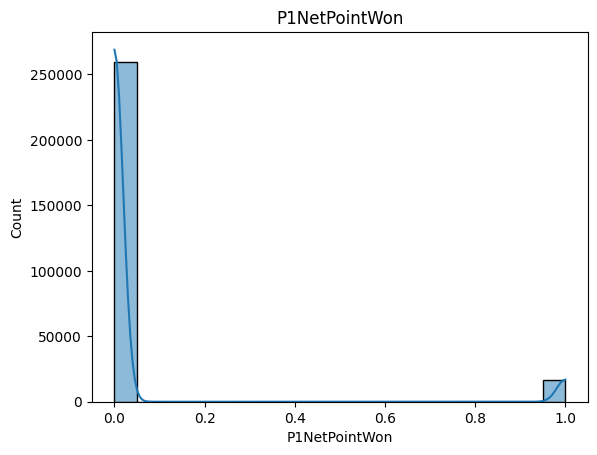

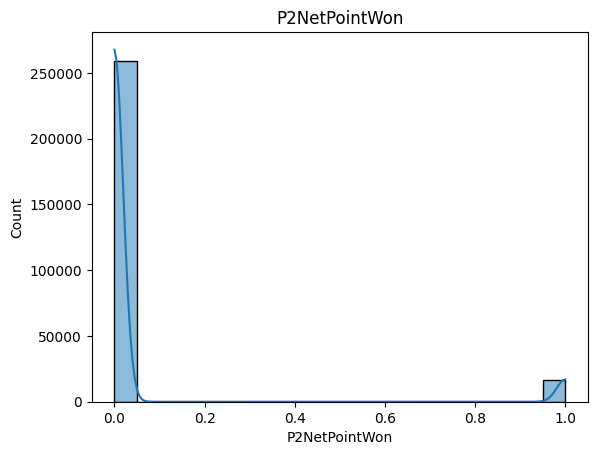

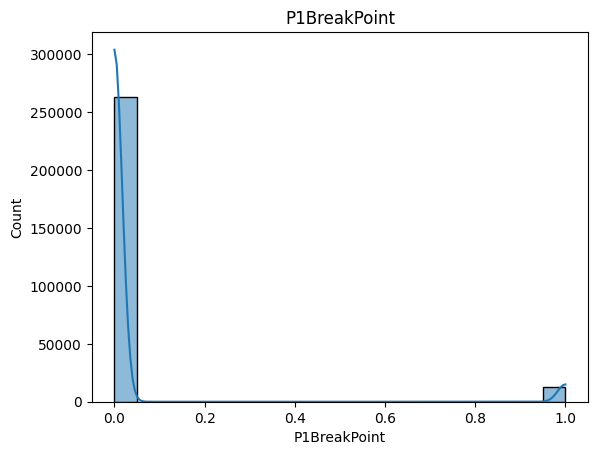

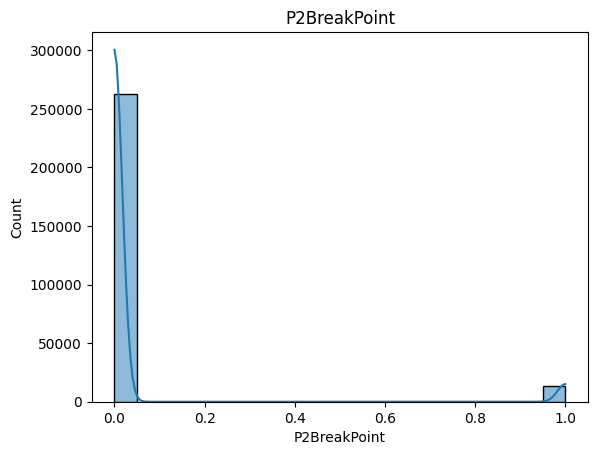

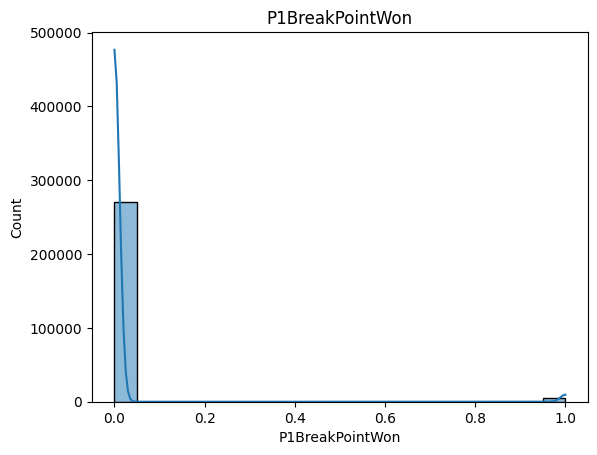

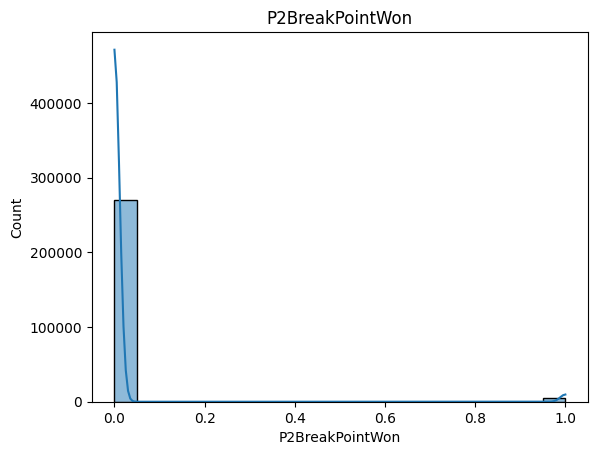

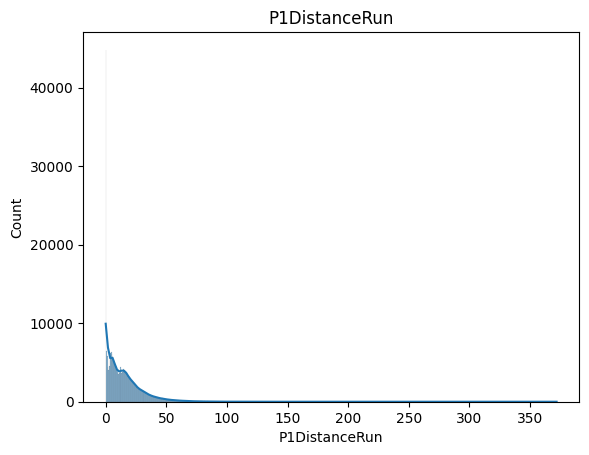

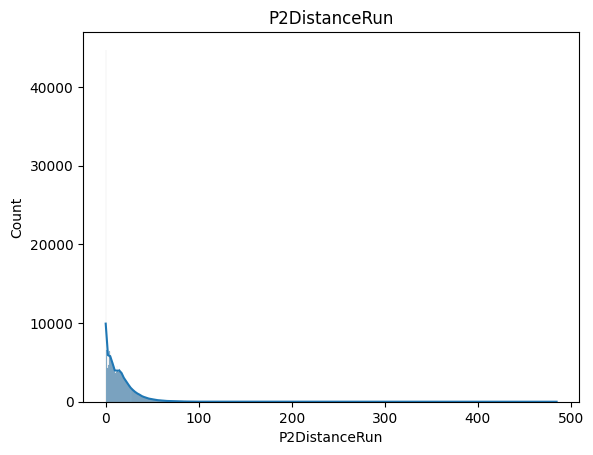

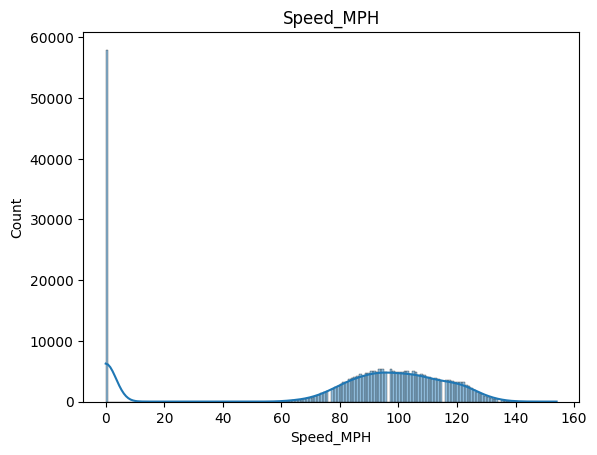

In [ ]:
#get the core cols and their plots to detect abnormal data
for col in cols:
    plt.figure()
    sns.histplot(df1[col], kde=True)
    plt.title(col)
    plt.show()


In [ ]:
serve_zero_df = df1[df1['ServeNumber'] == 0]
print(f"Number of rows with ServeNumber = 0: {len(serve_zero_df)}")

# Check if these are associated with specific events like Double Faults
display(serve_zero_df[['match_id', 'PointNumber', 'P1DoubleFault', 'P2DoubleFault', 'PointWinner', 'RallyCount']].head(10))

Number of rows with ServeNumber = 0: 13221


,match_id,PointNumber,P1DoubleFault,P2DoubleFault,PointWinner,RallyCount
3,2019-usopen-1101,2,1,0,2,0
21,2019-usopen-1101,20,0,1,1,0
80,2019-usopen-1101,79,0,1,1,0
81,2019-usopen-1101,80,0,1,1,0
97,2019-usopen-1101,96,0,1,1,0
106,2019-usopen-1101,105,1,0,2,0
117,2019-usopen-1101,116,1,0,2,0
156,2019-usopen-1101,155,0,1,1,0
168,2019-usopen-1102,1,1,0,2,0
188,2019-usopen-1102,21,1,0,2,0


In [ ]:
# Check if every ServeNumber = 0 row is a double fault
exceptions = df1[(df1['ServeNumber'] == 0) & (df1['P1DoubleFault'] == 0) & (df1['P2DoubleFault'] == 0)]

if exceptions.empty:
    print("Confirmed: All rows where ServeNumber = 0 are indeed Double Faults.")
else:
    print(f"Found {len(exceptions)} rows where ServeNumber = 0 but no Double Fault was recorded.")
    display(exceptions.head())

Confirmed: All rows where ServeNumber = 0 are indeed Double Faults.


In [ ]:
df1[(df1['P1Ace'] == 1) | (df1['P2Ace'] == 1)]['RallyCount']

,RallyCount
12,1
45,1
66,1
86,1
90,1
...,...
278771,1
278774,1
278819,1
278834,1


In [ ]:
# Replace 0 with NaN so we can use fillna
df1.loc[df1['RallyCount'] == 0, 'RallyCount'] = np.nan

# Create the ace flag
df1['is_ace'] = ((df1['P1Ace'] == 1) | (df1['P2Ace'] == 1)).astype(int)

# Instead of an 'if' statement, use .loc to fill RallyCount for aces
# Since an ace is by definition 1 shot, we can safely fill these NaNs with 1
df1.loc[(df1['is_ace'] == 1) & (df1['RallyCount'].isna()), 'RallyCount'] = 1

In [ ]:
df1['RallyCount'].isna().sum()

np.int64(34193)

In [ ]:
# Now use the grouping logic for the remaining non-ace NaNs
df1['RallyCount'] = df1['RallyCount'].fillna(
    df1.groupby(['SetNo', 'ServeNumber'])['RallyCount'].transform('mean')
)

# Clean up temporary column
df1.drop(columns=['is_ace'], inplace=True)

print(f"Remaining NaNs in RallyCount: {df1['RallyCount'].isna().sum()}")

Remaining NaNs in RallyCount: 7709


In [ ]:
# Identify why some groups failed (they had no non-null values to average)
remaining_nans = df1['RallyCount'].isna().sum()
print(f"Remaining NaNs before fallback: {remaining_nans}")

df1['RallyCount'] = df1['RallyCount'].fillna(
    df1.groupby(['SetNo'])['RallyCount'].transform('mean')
)

print(f"Final missing RallyCount values: {df1['RallyCount'].isna().sum()}")
display(df1['RallyCount'].describe())

Remaining NaNs before fallback: 7709
Final missing RallyCount values: 0


,RallyCount
count,275712.000000
mean,3.664362
std,3.200256
min,1.000000
25%,1.000000
50%,3.000000
75%,4.239705
max,55.000000


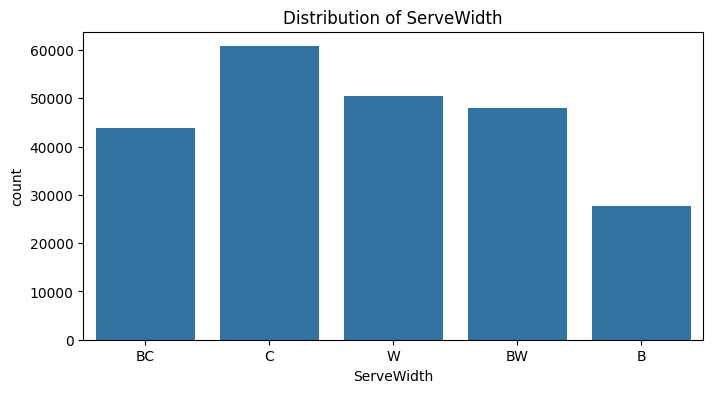

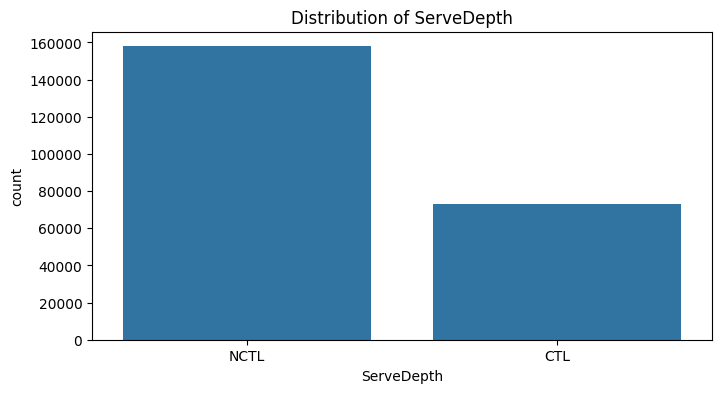

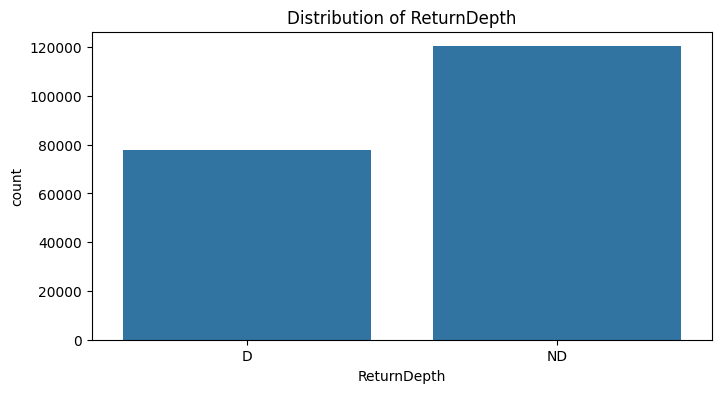

In [ ]:
col_c = ['ServeWidth', 'ServeDepth', 'ReturnDepth']

# Plotting categorical counts individually to avoid the concatenation error
for col in col_c:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df1, x=col)
    plt.title(f'Distribution of {col}')
    plt.show()

In [ ]:
df1[col_c].isna().sum()

,0
ServeWidth,44749
ServeDepth,44749
ReturnDepth,77483


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 275712 entries, 2 to 278893
Data columns (total 46 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   match_id            275712 non-null  object 
 1   ElapsedTime         275712 non-null  object 
 2   SetNo               275712 non-null  int64  
 3   P1GamesWon          275712 non-null  int64  
 4   P2GamesWon          275712 non-null  int64  
 5   SetWinner           275712 non-null  int64  
 6   GameNo              275712 non-null  int64  
 7   GameWinner          275712 non-null  int64  
 8   PointNumber         275712 non-null  int64  
 9   PointWinner         275712 non-null  int64  
 10  PointServer         275712 non-null  int64  
 11  P1Score             275712 non-null  object 
 12  P2Score             275712 non-null  object 
 13  P1Momentum          275712 non-null  int64  
 14  P2Momentum          275712 non-null  int64  
 15  P1PointsWon         275712 non-null  in